In [1]:
# System and environment variables
import os
from dotenv import load_dotenv
import zipfile

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization and analysis
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
import os
from dotenv import load_dotenv

# Loading the environment variables containing the Kaggle API token
load_dotenv('Kaggle_token.env')

# Importing the Kaggle API explicitly after loading the environment variables
from kaggle.api.kaggle_api_extended import KaggleApi

# Initializing and authenticating the Kaggle API client
api = KaggleApi()
api.authenticate()

# Downloading and extracting the dataset directly into the current working directory
print("Downloading and extracting dataset...")
api.dataset_download_files('laotse/credit-risk-dataset', path='.', force=True, unzip=True)

print("Dataset successfully downloaded and extracted.")

Dataset URL: https://www.kaggle.com/datasets/laotse/credit-risk-dataset
Dataset successfully downloaded and extracted.


In [3]:
# Reading the file
cr = pd.read_csv('credit_risk_dataset.csv')

In [4]:
# View of the first 5 rows
cr.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
# Statistical information about the data
cr.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
# Information about the collumns
cr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
# Average Loan amount by loan Intent
cr.groupby('loan_intent')['loan_amnt'].mean()

loan_intent
DEBTCONSOLIDATION     9594.886800
EDUCATION             9482.678599
HOMEIMPROVEMENT      10360.520111
MEDICAL               9259.582441
PERSONAL              9573.772867
VENTURE               9583.777758
Name: loan_amnt, dtype: float64

In [8]:
# Filtering high-risk customers: Default status (1) and renting
riskycustomers = cr[(cr['loan_status'] == 1) & (cr['person_home_ownership']== 'RENT')]

In [9]:
riskycustomers

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32563,52,71520,RENT,0.0,EDUCATION,E,7000,16.82,1,0.10,Y,24
32565,57,40000,RENT,1.0,MEDICAL,A,15000,8.90,1,0.38,N,21
32571,60,45600,RENT,1.0,VENTURE,B,20000,10.00,1,0.44,N,26
32574,52,65004,RENT,4.0,PERSONAL,D,20000,15.58,1,0.31,Y,19


In [10]:
# Loan amount by loan intention from risky customers
riskycustomers.groupby('loan_intent')['loan_amnt'].sum()

loan_intent
DEBTCONSOLIDATION    10803925
EDUCATION             9559475
HOMEIMPROVEMENT       6541400
MEDICAL              11857200
PERSONAL              9000575
VENTURE               8103200
Name: loan_amnt, dtype: int64

In [11]:
# Filling NA values on loan_int_rate using the median
# NA values represents over 3000 people, thats close to 10% of our data
cr['loan_int_rate'] = cr['loan_int_rate'].fillna(cr['loan_int_rate'].median())

In [12]:
# Updating Dataframe with correct information
# Removing extreme outliers: Age above 100 years and employment length greater than 60 years
cr =  cr[(cr['person_age'] <= 100) & (cr['person_emp_length'] <= 60)]

In [13]:
# Checking the Dataframe updated
cr.isna().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

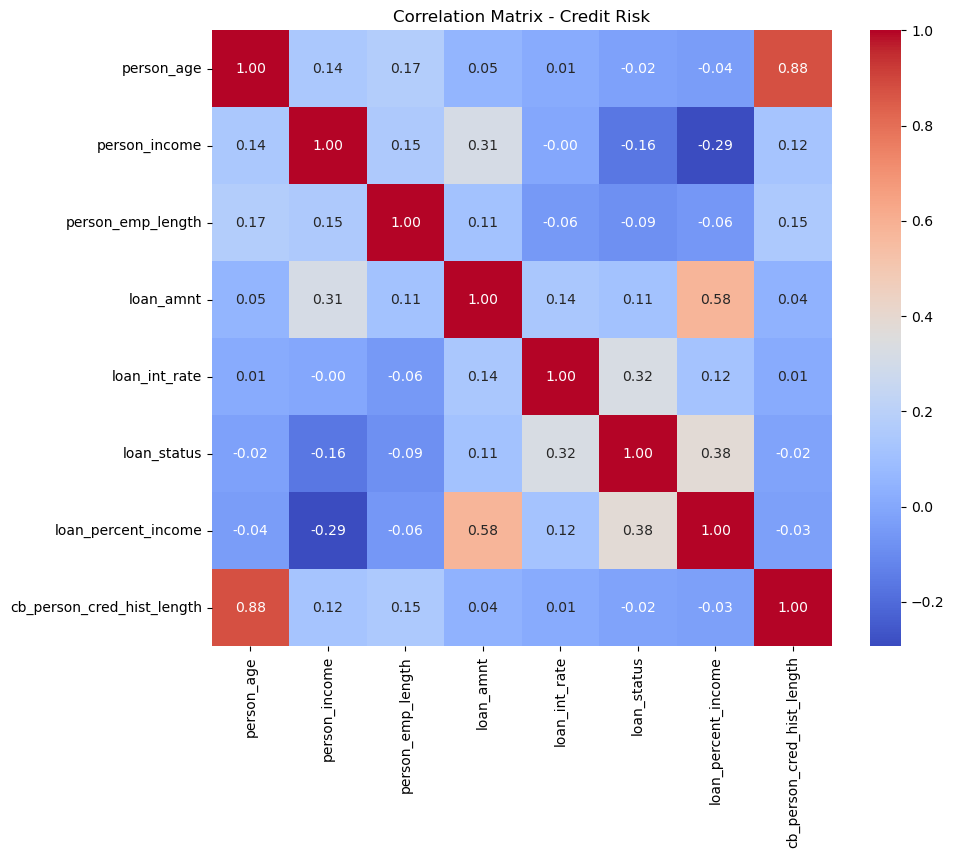

In [14]:
# Generating a correlation matrix for numerical features to identify relationships with loan_status
plt.figure(figsize=(10, 8))
correlation_matrix = cr.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix - Credit Risk")
plt.show()

In [15]:
# Separating features (X) and the target variable (y)
X = cr.drop('loan_status', axis=1)
y = cr['loan_status']

In [16]:
# Converting categorical variables into dummy/indicator variables (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

In [17]:
# Splitting the dataset into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"total Data: {len(X)}")
print(f"Trained Data: {len(X_train)}")
print(f"Tested Data (30%): {len(X_test)}")

total Data: 31679
Trained Data: 22175
Tested Data (30%): 9504


In [18]:
# Initializing the StandardScaler to normalize feature distributions
scaler = StandardScaler()

# Fitting the scaler on training data and transforming both train and test sets to prevent data leakage
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

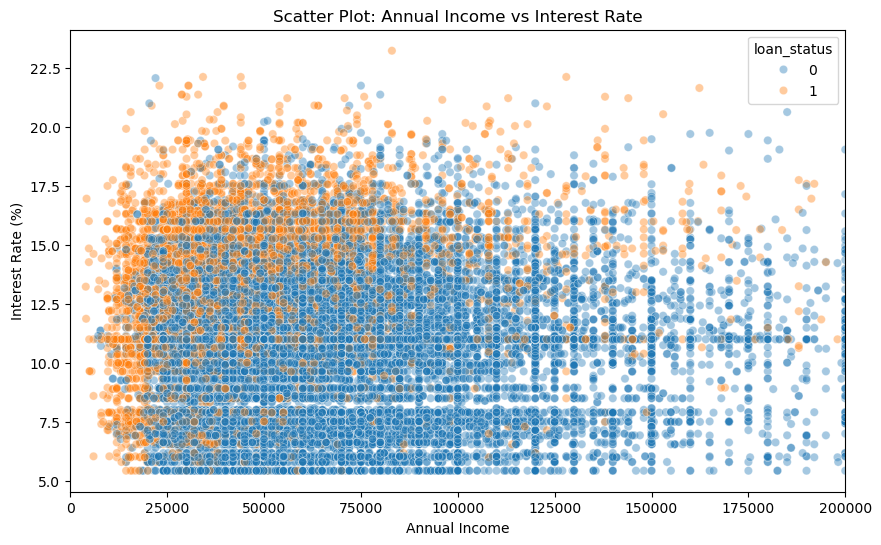

In [19]:
# Generating a Scatter Plot to visualize the separation of classes (Default vs Paid)
plt.figure(figsize=(10, 6))

# Plotting Income vs Interest Rate, coloring by loan_status
# alpha=0.4 makes points transparent to reveal overlapping data density
sns.scatterplot(data=cr, x='person_income', y='loan_int_rate', hue='loan_status', alpha=0.4)

# Limiting the X axis to 200,000 to avoid extreme outliers squishing the plot
plt.xlim(0, 200000)

plt.title("Scatter Plot: Annual Income vs Interest Rate")
plt.xlabel("Annual Income")
plt.ylabel("Interest Rate (%)")
plt.show()

In [20]:
# --- K-Nearest Neighbors (k-NN) Model ---
# Initializing and training the k-NN classifier
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [21]:
# Predicting the test set results
y_pred_knn = knn.predict(X_test)

In [22]:
# --- Support Vector Machine (SVM) Model ---
# Initializing and training the SVM classifier with a linear kernel
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [23]:
# Predicting the test set results
y_pred_svm = svm.predict(X_test)

In [24]:
# --- Model Evaluation ---
# Comparing model performances using classification reports to evaluate Precision, Recall, and F1-Score
print("--- K-NN Performance ---")
print(classification_report(y_test, y_pred_knn))

print("\n--- SVM Performance ---")
print(classification_report(y_test, y_pred_svm))

--- K-NN Performance ---
              precision    recall  f1-score   support

           0       0.90      0.97      0.94      7486
           1       0.85      0.61      0.71      2018

    accuracy                           0.89      9504
   macro avg       0.88      0.79      0.82      9504
weighted avg       0.89      0.89      0.89      9504


--- SVM Performance ---
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      7486
           1       0.75      0.56      0.64      2018

    accuracy                           0.87      9504
   macro avg       0.82      0.75      0.78      9504
weighted avg       0.86      0.87      0.86      9504



In [26]:
# Exporting the cleaned dataset to a CSV file for Power BI visualization
cr.to_csv('credit_risk_cleaned.csv', index=False)
print("Clean dataset exported successfully!")

Clean dataset exported successfully!
